<a href="https://colab.research.google.com/github/Nick-Apalis/PSYL-Fourier-Signals-Lab/blob/main/Piano_strings_%5Bupdated_code_2026%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wave dispersion in piano strings

Welcome to the data processing notebook for "Wave dispersion in piano strings"! This notebook includes templates for and information on the following:

1) Loading your data.

2) Applying a Fourier transform to the data.

3) Applying SciPy's peak-finding algorithm to determine peaks.

4) Plotting the difference between your data and the linear model extrapolated from the first harmonic and perform a curve fit to find the inharmonicity paramater $\varepsilon$. Previous versions used the lmfit package to perform the curve fit. Now this is just done in scipy.

You will need to manually input your file name, plot titles and some constants

## 1) Loading packages and reading data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math as math
import scipy as scipy
from scipy import io, signal
from scipy.io import wavfile
from scipy.optimize import curve_fit
import re

plt.close ("all")

In [ ]:
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Constant calculations here!

In [158]:
inharmonicities=[]

inharmonicitiesUnc=[]

tensions=[]

L=1.07 #@param
#Length of string here - keep it as a global variable for further function defrinitions to draw on

LUnc=0.005 #Uncertainty in length



m=0.0088 #@param {type:"number"}
#Mass of string in kg

mUnc=0.00005 #Uncertainty in mass


fracLUnc=(mUnc/L)**2

fracUncRest=(np.abs(m/(L**2))*LUnc)**2

mu=m/L

muUnc=np.sqrt(fracLUnc+fracUncRest)

print(f"Linear density is mu = {mu:0.4f} \u00b1 {muUnc:0.5f}")

Linear density is mu = 0.0082 ± 0.00006


##Files

Before running the next cell to import the data, complete the code with the filename of your input wavfile. The extension should also be included at the end.

You may need to convert the file provided to a .wav file using a program like audacity

500N-1C
Stereo file detected and converted to mono.
Duration = 6.946281179138322 s
546


/tmp/ipykernel_909/2421818728.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, stereo_data = scipy.io.wavfile.read(input_filename+".wav",mmap=False)


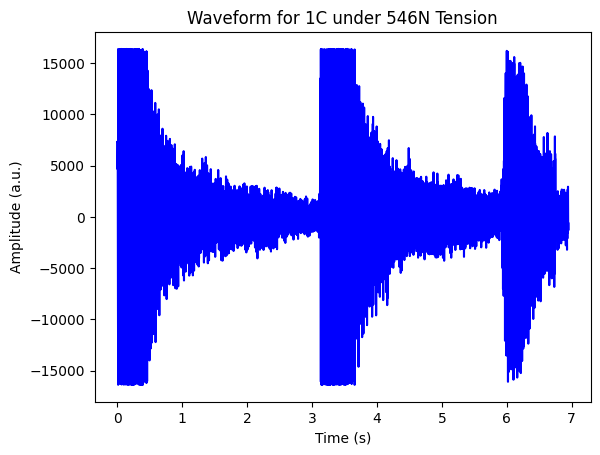

In [221]:
#Input the file path and name. In this version of the code, the filename should be input
#without the .wav at the end so we can use the filename later for titles.
FileForce=500 #@param
Type="1C" #@param
input_filename = f"{FileForce}N-{Type}"

#As the true tension is higher, it is imperative
currentTension = 546 # @param {"type":"number"}

print(input_filename)

directory = '/content/drive/MyDrive/PSYL Piano String Plots/' #GoogleDriveDir for saving

#directory = "C:\Users\nikol\OneDrive - Australian National University\Documents\University\Y3S1\PianoStringLab\Plots" #OS directory to which I'll save the files

#Read your audio file using SciPy's wavfile read. The wavefile read gives both the samplerate
#and stereo data of the audio file, so we need to label outputs correctly.
samplerate, stereo_data = scipy.io.wavfile.read(input_filename+".wav",mmap=False)

if len(stereo_data.shape) > 1:
    # It's stereo, so we blend the two channels
    mono_data = 1/2 * np.add(stereo_data[:,0], stereo_data[:,1])
    print("Stereo file detected and converted to mono.")
else:
    # It's already mono, so just use it as is!
    mono_data = stereo_data
    print("Mono file detected; no conversion needed.")

#Calculate the total time of the audio file. If all goes well, this number should match
#well with the graph output.
total_time = len(mono_data)/samplerate
print("Duration =",total_time,"s")


#Define a time vector for the x axis of the plot.
tarray = np.arange(0,len(mono_data)/samplerate,1/samplerate,dtype=None)

#rawTension=re.findall(r'\d+',input_filename)

#currentTension = ".join(rawTension)"

#prevTension=340 # @param {"type":"number"}
print(currentTension)

#Use matplotlib to plot.
plt.plot(tarray,mono_data,"b")
plt.title(f"Waveform for {Type} under {currentTension}N Tension")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.savefig(directory + f'{input_filename}_waveform.pdf', bbox_inches='tight')
plt.show()

The SciPy wavfile read will return very big magnitudes. Can you think of any particular reason why the magnitudes are so large? Can you correct or account for, or even ignore the large magnitudes?

## 2) Fourier transform the data

SciPy has built-in functions to Fourier transform the data and construct a vector for frequencies. Proportionality is maintained between the time series and Fourier data, which is why the magnitudes will again be very large.

It is strongly recommended to find a way to save these plots as high resolution images via matplotlib (plt) rather than screenshotting for your final assessments. I suggest looking up matplotlib.savefig in order to accomplish this.

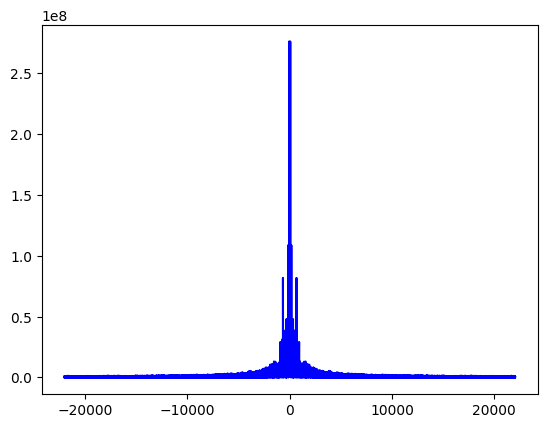

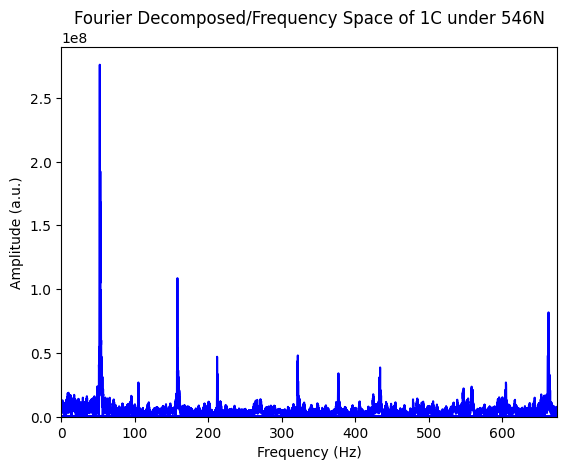

In [223]:
#Calculate the Fourier transform.
FourierMono=np.fft.fft(mono_data)
FourierMonoFrequency=np.fft.fftfreq(len(mono_data),1/samplerate) #(length of data, spacing between datapoints)


#SET LIMITS

bottomLim=0 #@param {type:"slider", min:0, max:100, step:1}
freqLim = 675 # @param {"type":"slider","min":0,"max":2000,"step":1}


#Plot the entire spectrum.
plt.plot(FourierMonoFrequency,np.abs(FourierMono),"b-")
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()

#Zoom into the graph to better see the peaks.
plt.plot(FourierMonoFrequency,np.abs(FourierMono),"b-")
plt.xlim(bottomLim,freqLim)
plt.ylim(0,)
plt.title(f"Fourier Decomposed/Frequency Space of {Type} under {currentTension}N")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (a.u.)")
#plt.savefig(directory + f'{input_filename}_frequencySpace.pdf')
plt.show()

Note that we can limit our analysis only to the positive frequencies in the Fourier data.

## 3) Finding Peaks Using Scipy's Peak Find

Scipy's signal.find_peaks function takes an array and searches for peaks based on the height, prominence, threshold, distance and width of the peaks. You should adjust these numbers until you get the appropriate peaks for your dataset. Here is the package documentation for further detail:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html

You may wish to include more parameters to improve the peak find. Here is an explanation of the two basic parameters included in this code template:

Distance tells the peak find how far apart you expect the peaks to be. This can be helpful in ruling out noise between the peaks.

Prominence tells the peak find how much you expect the peak to stand out from the baseline of the signal. It may be helpful to adjust your y limit as you investigate your data to help determine prominence. If you haven't adjusted your intensities in any way, you may have to set a very large prominence - bear in mind the exponent on your fourier plot.

First harmonic estimated to be at 40. Previous tension : 340


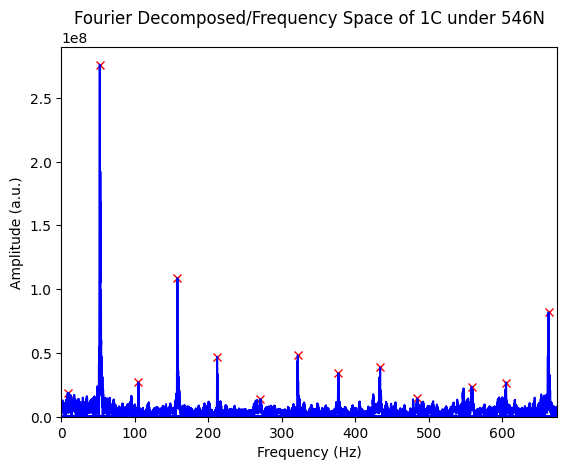

In [224]:
#To set a distance between peaks, manually input a rough estimate of the first harmonic
#based on the Fourier transform plot. Make sure it is slightly smaller.

#prevHarmonic1st=130
Harmonic1st = 40 #@param {type:"number"}
print(f"First harmonic estimated to be at {Harmonic1st}. Previous tension : {prevTension}")
distance = Harmonic1st*len(FourierMonoFrequency)/samplerate
#As the peak-finding code runs off a single array, distance needs to be scaled so that
#we have distance in array position rather than in any standard units.
#The prominence parameter sets a threshold below which no peak will be detected.
#You will need to decide prominence based on the values of your Fourier transform,
#which should be quite large. Take notice of the exponent!
prominence = 0.1e8 #@param {type:"number"}



#Run the peak-finding code using the parameters set above.
peaks = scipy.signal.find_peaks(np.abs(FourierMono),prominence=prominence,distance=distance)

#As SciPy will output additional data as well as the peak positions, the list of
#peak positions needs to be isolated from the output.
#Only the positive resonances are pulled out of the peak frequencies.
PeakFreqAll = FourierMonoFrequency[peaks[0]]
PeakFreq = [f for f in PeakFreqAll if f>0 and f<freqLim]

#Plot the data and highlight the peaks.
plt.plot(PeakFreqAll,np.abs(FourierMono[peaks[0]]),"xr")
plt.plot(FourierMonoFrequency,np.abs(FourierMono),"b-")
plt.xlim(0, freqLim)
plt.ylim(0, )
plt.title(f"Fourier Decomposed/Frequency Space of {Type} under {currentTension}N")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (a.u.)")
plt.savefig(directory + f'{input_filename}_frequencySpace.pdf', bbox_inches='tight')
plt.show()

You should visually check whether your peak find matches your dataset - you may need to mess with the xlim and ylim to investigate the lower intensity peaks.

With the sample data set, you should be able to find some set of peak find parameters that cleanly finds the first 8 modes.

##Run for ghost frequencies (at beginning and pop at end)

In [225]:
del PeakFreq[0]
print(PeakFreq)

[np.float64(52.40214016864111), np.float64(104.94824226082244), np.float64(158.07019204716468), np.float64(212.05591337474823), np.float64(271.08030202623956), np.float64(321.89886103593824), np.float64(377.1802396753838), np.float64(433.9012375502316), np.float64(484.43187271284984), np.float64(558.4283014125243), np.float64(605.0719646395565), np.float64(663.0886198262664)]


In [230]:
PeakFreq.pop()

np.float64(558.4283014125243)

## 4) Finding the Stiffness Parameter

Now that we have the resonance peaks from the data, we can plot them against a linear model and use the differences to find the inharmonicity coefficient $\varepsilon$.

Previous versions of this created a model based only on integer multiples of the first harmonic: $f_n = n f_\textrm{R}$. This had issues with peaks that were skipped by the peak find.

This version divides each frequency by the fundamental and rounds to the nearest integer to find the harmonic number. It assumes that the peak frequencies vary only small amounts from the ideal model. You can verify this by comparing the predicted mode numbers to what you expect by examining your data.

In [231]:
#To create a linear model of resonances, we will first need to define the first harmonic
#and an array for the mode number.
FirstHarmonic = PeakFreq[0]

#Identify the modes found by
Modes = []
for i in range(len(PeakFreq)):
    ModeEstimate = PeakFreq[i]/FirstHarmonic
    Mode = np.round(ModeEstimate)
    Modes.append(Mode)
Modes = np.asarray(Modes)

#Create data for the linear model.
LinearModel = [n*FirstHarmonic for n in Modes]
print(Modes, LinearModel)

#Take error for measurements as the Fourier resolution
FourierResolution = samplerate/len(FourierMonoFrequency)

#Propogate error for the linear model
LinearErr = [(n*FirstHarmonic)*(FourierResolution/FirstHarmonic) for n in Modes]

[1. 2. 3. 4. 5. 6. 7. 8. 9.] [np.float64(52.40214016864111), np.float64(104.80428033728222), np.float64(157.20642050592335), np.float64(209.60856067456444), np.float64(262.01070084320554), np.float64(314.4128410118467), np.float64(366.8149811804878), np.float64(419.2171213491289), np.float64(471.61926151777)]


Included in this code is a simple uncertainty analysis that assumes the largest source of uncertainty is the distance between data points in the Fourier plot - that is, the resolution of the data.

Can you think of any other sources of uncertainty? Ideally you should find a way to quantify each of these sources of uncertatiny. Even if you don't quantitatively account for these, it is an important skill in signal processing to be able to identify, discuss, and consider ways to account for these uncertainties.

##Plotting Lin Mod vs Data Model - not insightful

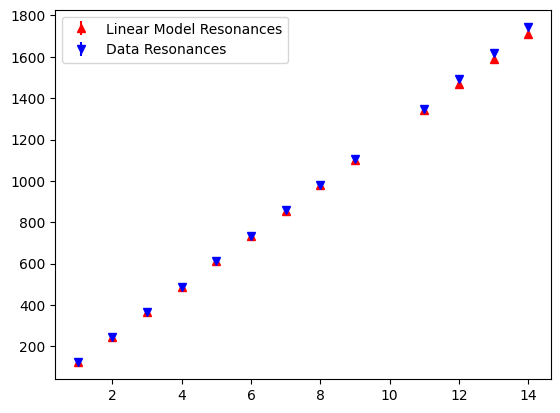

In [97]:


#Plot the frequencies
plt.errorbar(Modes, LinearModel,yerr=LinearErr,label="Linear Model Resonances",fmt="r^")
plt.errorbar(Modes, PeakFreq,yerr=FourierResolution,label="Data Resonances",fmt="bv")
plt.legend(loc="upper left")
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()

##Plotting differences (insightful)

We can now estimate the inharmonicity coefficient through square difference equation: $$f^{(\varepsilon)^2}_n - (nf_R)^2 = \varepsilon\frac{n^4 \pi^2}{4L^4}$$

First, let's find and plot the square differences

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_909/116955164.py:27: SyntaxWarning: invalid escape sequence '\e'
  label=f"Fit with inharmonicity coefficient, $\epsilon=${popt[0]:.2f} \u00b1 {perr[0]:.2f} \n \u03bc = {mu:0.4f} \u00b1 {muUnc:0.5f} kg/m")


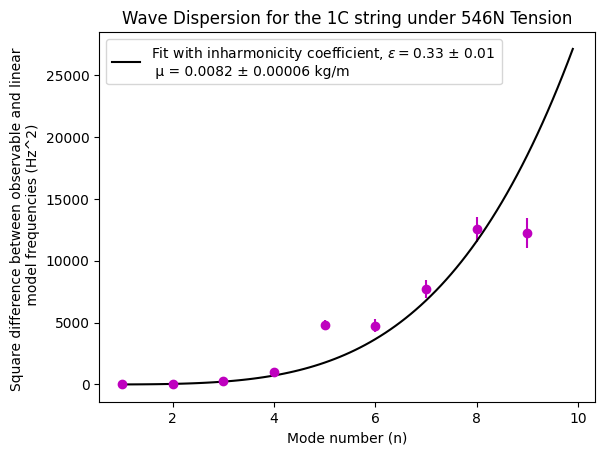

epsilon is 0.3346570246082192 with uncertainty 0.014582218694919422


'\n#Note that as we are subtracting the square of large numbers, the magnitude of\n#the square differences can get very large.\nplt.errorbar(Modes,SquareDifferences,yerr=SquareDifferenceError,fmt="mo")\nplt.title("")\nplt.xlabel("")\nplt.ylabel("")\n#plt.show()'

In [232]:
#Calculate the differences of the square of the two numbers, along with
#the associated error.
SquareDifferences = np.subtract(np.square(PeakFreq),np.square(LinearModel))
DataSquareError = 2*np.multiply(PeakFreq,FourierResolution)
LinearSquareError = 2*np.multiply(LinearModel,LinearErr)
SquareDifferenceError = np.sqrt(np.add(np.square(LinearSquareError),np.square(DataSquareError)))

#Define the model as a function of n (mode number), epsilon
#(inharmonicity coefficient) and L (length of the string).
def LinearStiffDif(n, epsilon):
    L = 1.04 # to be editted to your data
    return epsilon*math.pi**2*n**4/(L**4)

popt, pcov = curve_fit(LinearStiffDif, Modes,
                       SquareDifferences, sigma = SquareDifferenceError,
                      absolute_sigma = True)
perr = np.sqrt(np.diag(pcov))

# Now let's create a dummy xarray to plot the fitted curve over,
# and propogate that to get the fitted curve.
xarray = np.arange(Modes[0], Modes[-1] + 1, 0.1)
FittedCurve = LinearStiffDif(xarray, popt)

plt.errorbar(Modes, SquareDifferences, yerr=SquareDifferenceError,
             fmt="mo", label = "")
plt.plot(xarray, FittedCurve, "k-",
         label=f"Fit with inharmonicity coefficient, $\epsilon=${popt[0]:.2f} \u00b1 {perr[0]:.2f} \n \u03bc = {mu:0.4f} \u00b1 {muUnc:0.5f} kg/m")
plt.legend(loc="upper left")
plt.title(f"Wave Dispersion for the {Type} string under {currentTension}N Tension")
plt.xlabel("Mode number (n)")
plt.ylabel("Square difference between observable and linear \n model frequencies (Hz^2)")
plt.savefig(directory + f'{input_filename}_ModelDifference.pdf', bbox_inches='tight')
plt.show()

print("epsilon is", popt[0], "with uncertainty", perr[0])

"""
#Note that as we are subtracting the square of large numbers, the magnitude of
#the square differences can get very large.
plt.errorbar(Modes,SquareDifferences,yerr=SquareDifferenceError,fmt="mo")
plt.title("")
plt.xlabel("")
plt.ylabel("")
#plt.show()"""

##Info on fit

Now we define the equation in python, and use it to fit a curve to our data. Note that we have already taken the square difference, so all we need to account for is the RHS of the equation. You will need to change the inputted length to reflect conditions when taking data. The length for the sample code is provided for you.

Fitting is done in this version using the scipy.optimize function curve_fit. You can find the documentation for this package here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

In order to explain your data analysis in the report/poster, I recommend reading the curve_fit documentation. You do not need to provide a full explanation of the methods and analysis performed by the package. However, briefly identifying the processes used makes your data analysis as transparent as possible.

You will need to do your own work to make sure that the technical information on this graph is complete and presented appropriately.

There are some additional things you may need to add to this code in order to help with analysis/properly analyze this data:

- A comparison of tension, and testing the null hypothesis that inharmonicity is not tension dependant (see uncertainties and hypothesis testing document on Canvas Modules page)
- A background subtraction (this will help a lot with noise in particular)
- A reduced-chi squared fit for the inharmonicity values (see uncertainties and hypothesis testing document on Canvas Modules page)

And some more extension work if you are comfortable with Python:
- A method for determining line width of the peaks rather than just taking resolution as uncertainty
- An iterated loop that automates data processing and makes things a lot cleaner (this requires some knowledge of for loops and is not necessary, but will be a great template for you to use going forward in research if you do set it up)

If you are wondering how you might approach this, ask your demonstrator!

##To add to arrays

In [233]:
tensionUnc=5 #Tension uncertainties are set to 5N due to the movement of the digital tension measurements

if popt[0] not in inharmonicities:
    inharmonicities.append(popt[0])
    inharmonicitiesUnc.append(perr[0])

if currentTension not in tensions:
    tensions.append(currentTension)

print(tensions)
print(inharmonicities)
print(inharmonicitiesUnc)

for i in range(len(tensions)):
  currentTension=tensions[i]
  currentTensionUnc=tensionUnc
  #currentDensity=LinDensities[i]
  #currentDensityUnc=LinDensitiesUnc[i]
  currentInharmonicity=inharmonicities[i]
  currentInharmonicityUnc=inharmonicitiesUnc[i]
  print(f"For the 0C string (mu={mu:0.4f} \u00b1 {muUnc:0.5f}) under {currentTension}\u00b1{currentTensionUnc} N of tension, \nthe inharmonicity coefficient is {currentInharmonicity:.2f}\u00b1{currentInharmonicityUnc:.2f}")



[249, 368, 456, 546]
[np.float64(1.961249054297516), np.float64(0.21791426721976975), np.float64(0.3099127097402749), np.float64(0.3346570246082192)]
[np.float64(0.22201305221286957), np.float64(0.011647033067798428), np.float64(0.01082814781140723), np.float64(0.014582218694919422)]
For the 0C string (mu=0.0082 ± 0.00006) under 249±5 N of tension, 
the inharmonicity coefficient is 1.96±0.22
For the 0C string (mu=0.0082 ± 0.00006) under 368±5 N of tension, 
the inharmonicity coefficient is 0.22±0.01
For the 0C string (mu=0.0082 ± 0.00006) under 456±5 N of tension, 
the inharmonicity coefficient is 0.31±0.01
For the 0C string (mu=0.0082 ± 0.00006) under 546±5 N of tension, 
the inharmonicity coefficient is 0.33±0.01


##Plot inharmonicity VS tension and do NHST

In [126]:
from scipy import stats
from scipy.stats import chisquare

[203, 340, 436, 537, 632, 826]
[np.float64(0.37727329288056277), np.float64(0.28450196190284854), np.float64(0.15437686173272236), np.float64(0.08583807290593214), np.float64(0.044866467395793475), np.float64(0.3337868808591179)]
0.0027029636837141544
Reject the null hypothesis


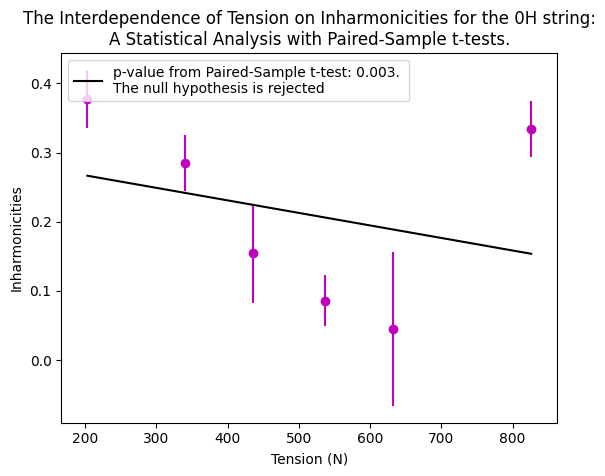

In [127]:
#Find curve of best fit
T, b = np.polyfit(tensions, inharmonicities, 1)

y_fit = T * np.array(tensions) + b

#Do independent t-tests between tension and inharmonicities
t_stat, p_value = stats.ttest_rel(np.array(tensions), inharmonicities)

print(tensions)
print(inharmonicities)
print(p_value)

if p_value < 0.05:
  H0="The null hypothesis is rejected"
  print("Reject the null hypothesis")
else:
  H0="The null hypothesis cannot be rejected"
  print("Fail to reject the null hypothesis")


plt.errorbar(tensions, inharmonicities, yerr=inharmonicitiesUnc,xerr=tensionUnc,
             fmt="mo", label = "")
plt.plot(tensions, y_fit, "k-",
         label=f"p-value from Paired-Sample t-test: {p_value:.3f}. \n{H0}")
plt.legend(loc="upper left")
plt.title(f"The Interdependence of Tension on Inharmonicities for the {Type} string:\nA Statistical Analysis with Paired-Sample t-tests.")
plt.xlabel("Tension (N)")
plt.ylabel("Inharmonicities")
plt.savefig(directory + f'{Type}_InharmonicityVSTension.pdf', bbox_inches='tight')
plt.show()

##Export to XLSX

In [128]:
import pandas as pd

data = {
    'Tension': tensions,
    'Tension Uncertainty': tensionUnc,
    'Linear Density': mu,
    'Linear Density Uncertainty': muUnc,
    'Inharmonicity Coefficient': inharmonicities,
    'Inharmonicity Uncertainty': inharmonicitiesUnc
}

df = pd.DataFrame(data)

excel_filename = f'FinalDataInharmonicities_{Type}.xlsx'
excel_filepath = directory + excel_filename

df.to_excel(excel_filepath, index=False)

print(f"Data successfully exported to {excel_filepath}")

#Clean up all arrays

inharmonicities=[]

inharmonicitiesUnc=[]

tensions=[]

Data successfully exported to /content/drive/MyDrive/PSYL Piano String Plots/FinalDataInharmonicities_0H.xlsx
